# Montandon EDA — schema, missingness, and linkage

Snapshot taken **2026-09-12** against `montandon-eoapi-stage.ifrc.org`. Every claim below sits directly above the cell that produces it. Raw pulls are cached under `data/raw/` (gitignored); the pull cell regenerates them.

**Caveat on all counts:** the staging database is being loaded live — `gdacs-events` grew from 43,595 to 43,723 items over ~4 hours on the day of the census. Treat every number as a snapshot.

## TL;DR

1. **The API schema (`api_schemas.py`) rejects ~97% of real items.** `monty:src_event_id` and `keywords` are required but present on only 1–31% of items. The schema matches what the current version of the Montandon ETL produces; ~97% of the bank was produced on other versions that predates those fields.
2. **The missing fields are missing by ETL generation, not by collection.** Items dated 2025+ have `keywords`; items dated 2026 also have `monty:src_event_id` and `processing:version 0.2.4`. Same pattern in every collection.
3. **`description` is mostly templated or placeholder text.** EM-DAT and GDACS are formulaic one-liners; 85% of IFRC event descriptions are the literal string `NA`, the rest raw HTML.
4. **`monty:corr_id` links events to impacts within a source (100%) but almost never across sources (0.8%).** GDACS puts its own event ID where EM-DAT puts `1`. IFRC's own cookbook links across sources by date + bbox + hazard code instead.
5. **`monty:hazard_codes` mixes at least three vocabularies** in one field (EM-DAT, UNDRR-ISC, GLIDE). The ETL repo ships the crosswalk that normalises them.
6. **`keywords` is derived from `hazard_codes` + `country_codes` by the ETL**, not source text. Reconstructible for the 97% missing it.
7. **EM-DAT geometry is full-resolution country polygons, up to 10 MB per item**, >99% of the payload, and duplicates `monty:country_codes`.

## Setup

In [1]:
from monty_tool.api_utils import get_pystac_client, get_collection_items
import os

from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(usecwd=True))


True

In [2]:
import re
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

# Fixed categorical order — a series keeps its colour no matter which chart it's in
COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
INK, INK_MUTED, GRID, AXIS = "#0b0b0b", "#52514e", "#e1e0d9", "#c3c2b7"
# Single-hue ramp for magnitude (heatmaps): light = low, dark = high
BLUES = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#3987e5", "#0d366b"])

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_MUTED,
    "xtick.color": "#898781", "ytick.color": "#898781",
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "legend.frameon": False, "legend.fontsize": 8,
})


def hbar(labels, values, title, color=COLORS[0], fmt="{:,.0f}", ax=None):
    """Horizontal bars, first label at the top, value printed at the end of each bar."""
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 0.32 * len(labels) + 1))
    bars = ax.barh(labels[::-1], values[::-1], color=color[::-1] if isinstance(color, list) else color, height=0.7)
    ax.bar_label(bars, labels=[fmt.format(v) for v in values[::-1]], padding=3, fontsize=8, color=INK_MUTED)
    ax.set_title(title)
    ax.grid(axis="y", visible=False)
    ax.margins(x=0.15)
    return ax

Smoke test through the validated path — works on the *newest* items, which is why the schema looked fine at first.

In [3]:
# Start small — max_items caps how many you pull
items = get_collection_items("emdat-events", max_items=20)

print(len(items))
first = items[0]
print(first.id, first.collection)
print(first.properties.title)
print(first.properties.monty_country_codes)
print(first.properties.start_datetime, first.properties.end_datetime)


20
emdat-event-2026-0571-ZWE emdat-events
Road in Zimbabwe
['ZWE']
2026-08-28 00:00:00+00:00 2026-08-28 00:00:00+00:00


## Collection census

The API doesn't report `numberMatched` on any endpoint, so `get_collection_counts()` pages every collection at 1,000 IDs per page (STAC `fields` extension strips everything else) and sums `numberReturned`. Hours on the staging server, so it's cached to `data/collection_counts.json`. `null` = uncounted: `usgs-events` passed 1M IDs after 6.5 h of paging and was cancelled; USGS hazards/impacts, PDC hazards/impacts, and DesInventar were never reached. All seven were already in the skip/sample tier.

Notable: every source has `events == hazards` exactly (1:1) except IFRC, which has **0** hazards. `ibtracs-hazards` is 722,837 — one item per storm-track observation, ~54 per storm. `cems-*`, `reference-events`, and `rsh-test2-events` are empty.

In [4]:
import json
from pathlib import Path

from monty_tool.api_utils import get_collection_counts

# data/ is gitignored, so this cache is local-only
counts_path = Path("../data/collection_counts.json")

if counts_path.exists():
    counts = json.loads(counts_path.read_text())
else:
    counts = get_collection_counts()
    counts_path.parent.mkdir(exist_ok=True)
    counts_path.write_text(json.dumps(counts, indent=2))

# keys starting with "_" are file metadata, not collections
rows = {k: v for k, v in counts.items() if not k.startswith("_")}
for cid, n in sorted(rows.items(), key=lambda kv: -(kv[1] or -1)):
    print(f"{n:>9,}  {cid}" if n is not None else f"{'(uncounted)':>9}  {cid}")
print(f"{sum(n for n in rows.values() if n):>9,}  TOTAL counted")

  722,837  ibtracs-hazards
  164,587  pdc-events
   64,637  emdat-impacts
   59,038  gdacs-hazards
   43,595  gdacs-events
   36,956  gdacs-impacts
   35,668  idmc-gidd-impacts
   32,558  idmc-idu-impacts
   25,308  emdat-events
   25,308  emdat-hazards
   21,161  idmc-idu-events
   19,230  idmc-gidd-events
   13,467  ibtracs-events
    8,523  glide-events
    8,523  glide-hazards
    2,199  ifrcevent-events
    1,826  gfd-impacts
    1,349  ifrcevent-impacts
      913  gfd-events
      913  gfd-hazards
        0  cems-events
        0  cems-hazards
        0  cems-impacts
        0  cems-response
(uncounted)  desinventar-events
(uncounted)  desinventar-impacts
        0  ifrcevent-hazards
(uncounted)  pdc-hazards
(uncounted)  pdc-impacts
        0  reference-events
        0  rsh-test2-events
(uncounted)  usgs-events
(uncounted)  usgs-hazards
(uncounted)  usgs-impacts
1,288,596  TOTAL counted


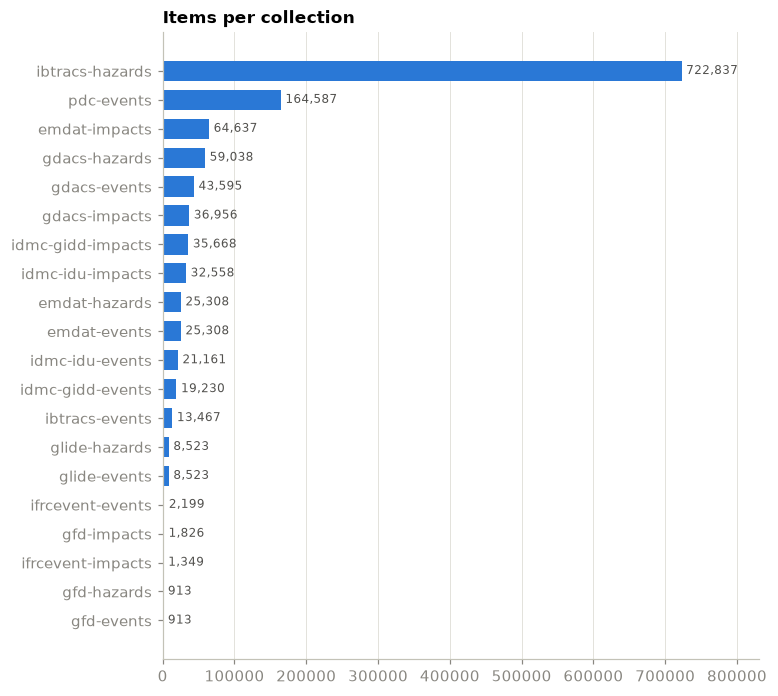

In [5]:
# Counted, non-empty collections only. ibtracs-hazards is one item per storm-track fix, so it dwarfs the rest.
census = sorted(((n, cid) for cid, n in rows.items() if n), reverse=True)
hbar([cid for _, cid in census], [n for n, _ in census], "Items per collection")
plt.show()

## Pulling the core collections

The core collections for all three tracks: EM-DAT (canonical disaster records + impacts, 1900–present), GDACS (second source with alert levels; the natural overlap test), and IFRC's own events/impacts (tiny, but the only operational-response data). ~137k items, 48 MB gzipped.

EM-DAT is pulled **without geometry**: its items carry full-resolution country MultiPolygons (mean 33 KB, max 10.8 MB for `emdat-event-2002-0495-CHL`), >99% of the payload, and a 1,000-item page times out the server's ~30 s gateway. `fields={"exclude": ["geometry"]}` is honoured server-side and cuts the pull from ~1.5 GB / 90 min to 10 MB / 4 min. `bbox` is kept; `country_codes` + any boundary set reproduces the polygon.

In [6]:
from pystac_client import Client

from monty_tool.api_utils import STAC_API_URL, _get_headers
from monty_tool.data_cache import load_collection, pull_collection, raw_cache_path

# EM-DAT geometry is >99% of its payload (full-res country polygons, up to 10 MB per Item)
# and duplicates monty:country_codes, so it's pulled without geometry.
TIER1 = {
    "emdat-events": False,
    "emdat-impacts": False,
    "gdacs-events": True,
    "ifrcevent-events": True,
    "ifrcevent-impacts": True,
}
CACHE_DIR = Path("../data/raw")

# The staging server silently drops connections under load; without a timeout a pull can hang forever
client = Client.open(STAC_API_URL, headers=_get_headers(), timeout=60)

for cid, geom in TIER1.items():
    if not raw_cache_path(cid, CACHE_DIR, geometry=geom).exists():
        pull_collection(cid, cache_dir=CACHE_DIR, client=client, geometry=geom)

raw = {cid: list(load_collection(cid, CACHE_DIR, geometry=geom)) for cid, geom in TIER1.items()}
for cid, items in raw.items():
    print(f"{len(items):>7,}  {cid}")

 25,308  emdat-events
 64,637  emdat-impacts
 43,723  gdacs-events
  2,199  ifrcevent-events
  1,349  ifrcevent-impacts


## Flatten to Polars

`items_to_frame` promotes `properties` to columns under their API names (`monty:corr_id`, not `monty_corr_id`) and flattens nested dicts with dotted keys (`monty:impact_detail.value`). Polars, to match the `embedding-setup` branch. Column null-rates *are* field coverage.

In [7]:
import polars as pl
from collections import Counter
from pydantic import ValidationError

from monty_tool.api_schemas import MontandonItem
from monty_tool.data_cache import items_to_frame

# Wider display defaults so the coverage / linkage tables below aren't truncated
pl.Config.set_tbl_rows(60)
pl.Config.set_tbl_cols(30)
pl.Config.set_fmt_str_lengths(70)

# One frame per collection, then a single tall frame. diagonal_relaxed fills columns a
# collection lacks (e.g. impact_detail.* on events) with null — those nulls are the coverage signal.
frames = {cid: items_to_frame(items) for cid, items in raw.items()}
df = pl.concat(frames.values(), how="diagonal_relaxed")

# Each collection keeps the same colour in every chart
COLL_COLOR = dict(zip(frames, COLORS))
df.shape

(137216, 30)

In [8]:
df.head(20)

id,collection,bbox,geometry_type,n_links,n_assets,roles,title,datetime,keywords,description,end_datetime,monty:etl_id,monty:corr_id,start_datetime,monty:hazard_codes,monty:src_event_id,processing:version,monty:country_codes,processing:software.pystac-monty,monty:episode_number,monty:impact_detail.type,monty:impact_detail.unit,monty:impact_detail.value,monty:impact_detail.category,monty:impact_detail.estimate_type,severitydata.severity,severitydata.severitytext,severitydata.severityunit,monty:guid
str,str,list[f64],str,i64,i64,list[str],str,str,list[str],str,str,str,str,str,list[str],str,str,list[str],str,i64,str,str,f64,str,str,f64,str,str,str
"""emdat-event-2026-0571-ZWE""","""emdat-events""","[25.238, -22.415, … -15.632]",null,7,0,"[""source"", ""event""]","""Road in Zimbabwe""","""2026-08-28T00:00:00Z""","[""Benzene & Hydrocarbons"", ""Zimbabwe"", … ""Chemical""]","""Road in Near Chivhu, Zimbabwe of August 2026""","""2026-08-28T00:00:00Z""","""aa6feae6-afaa-46a9-911f-8d60a0e493a3""","""20260828-ZWE-638247-TL0405-1-GCDB""","""2026-08-28T00:00:00Z""","[""TL0405"", ""AC"", ""tec-tra-roa-roa""]","""2026-0571-ZWE""","""0.2.4""","[""ZWE""]","""0.2.4""",1,null,null,null,null,null,null,null,null,null
"""emdat-event-2026-0561-PAK""","""emdat-events""","[60.866, 23.688, … 36.897]",null,7,0,"[""source"", ""event""]","""Fire (Miscellaneous) in Pakistan of August 2026""","""2026-08-26T00:00:00Z""","[""Pakistan"", ""Industrial Failure"", … ""Technological""]","""Fire (Miscellaneous) in Islamabad, Pakistan of August 2026""","""2026-08-26T00:00:00Z""","""5450fae7-cada-443b-b1df-a9b96572d870""","""20260826-PAK-1083041-TL0305-1-GCDB""","""2026-08-26T00:00:00Z""","[""TL0305"", ""FR"", ""tec-mis-fir-fir""]","""2026-0561-PAK""","""0.2.4""","[""PAK""]","""0.2.4""",1,null,null,null,null,null,null,null,null,null
"""emdat-event-2026-0558-FRA""","""emdat-events""","[-4.777, 41.365, … 51.091]",null,10,0,"[""source"", ""event""]","""Tornado in France""","""2026-08-24T00:00:00Z""","[""Wind & Pressure-related"", ""France"", … ""Tornado""]","""Storm in Pomas (Corbières, Aude department), France of August 2026""","""2026-08-24T00:00:00Z""","""729668af-5e35-4174-bfd3-70b69c86a2af""","""20260824-FRA-1224913-MH0305-1-GCDB""","""2026-08-24T00:00:00Z""","[""MH0305"", ""TO"", ""nat-met-sto-tor""]","""2026-0558-FRA""","""0.2.4""","[""FRA""]","""0.2.4""",1,null,null,null,null,null,null,null,null,null
"""emdat-event-2026-0562-IND""","""emdat-events""","[68.144, 6.753, … 33.171]",null,9,0,"[""source"", ""event""]","""Water in India of August 2026""","""2026-08-22T00:00:00Z""","[""Benzene & Hydrocarbons"", ""Carcinogens"", … ""Chemical""]","""Water in Odishae state, India of August 2026""","""2026-08-22T00:00:00Z""","""a7bd1eb6-ab53-4785-8f6e-4e15b751e040""","""20260822-IND-989514-TL0403-1-GCDB""","""2026-08-22T00:00:00Z""","[""TL0403"", ""AC"", ""tec-tra-wat-wat""]","""2026-0562-IND""","""0.2.4""","[""IND""]","""0.2.4""",1,null,null,null,null,null,null,null,null,null
"""emdat-event-2026-0553-TUN""","""emdat-events""","[7.493, 30.234, … 37.34]",null,9,0,"[""source"", ""event""]","""Water in Tunisia of August 2026""","""2026-08-21T00:00:00Z""","[""Benzene & Hydrocarbons"", ""Carcinogens"", … ""Chemical""]","""Water in Zarzi, Tunisia of August 2026""","""2026-08-22T00:00:00Z""","""fbb903fd-4447-4d3d-b7ec-2ed6569eb9b9""","""20260821-TUN-1113348-TL0403-1-GCDB""","""2026-08-21T00:00:00Z""","[""TL0403"", ""AC"", ""tec-tra-wat-wat""]","""2026-0553-TUN""","""0.2.4""","[""TUN""]","""0.2.4""",1,null,null,null,null,null,null,null,null,null
"""emdat-event-2026-0545-BRA""","""emdat-events""","[-74.005, -33.741, … 5.273]",null,7,0,"[""source"", ""event""]","""Road in Brazil""","""2026-08-19T00:00:00Z""","[""Benzene & Hydrocarbons"", ""Carcinogens"", … ""Brazil""]","""Road in Ipiranga (Parana state), Brazil of August 2026""","""2026-08-19T00:00:00Z""","""24372e18-0204-4f37-a78d-c3fa70d9c8b7""","""20260819-BRA-681029-TL0405-1-GCDB""","""2026-08-19T00:00:00Z""","[""TL0405"", ""AC"",

## 1. Field coverage

% of items with a non-null value, per field, per collection. **Every key the API returns is here** — including ones not in `api_schemas.py` (`monty:etl_id`, `monty:guid`, `processing:*`), which `extra="ignore"` drops silently.

What to look for:
- `keywords` 1–31%, `monty:src_event_id` 0–21% — both **required** in the schema.
- `monty:impact_detail.unit` is 100% on EM-DAT impacts and **0%** on IFRC impacts. Also required.
- `severitydata` is a GDACS field the schema puts on *impact* properties; here it's on 31% of GDACS *events*.
- `geometry_type` 0% on EM-DAT is our pull (`geometry=False`), not the API.

In [9]:
# Identity / bookkeeping columns that are trivially 100%
SKIP = {"id", "collection", "bbox", "n_links", "n_assets"}
coverage = (
    df.group_by("collection")
    # % non-null per column, per collection
    .agg([(pl.col(c).is_not_null().mean() * 100).round(0).alias(c) for c in df.columns if c not in SKIP])
    # long form (collection, field, pct) then re-pivot so fields are rows and collections are columns
    .unpivot(index="collection", variable_name="field", value_name="pct")
    .pivot(on="collection", index="field", values="pct")
    .sort("field")
)
coverage

field,emdat-events,ifrcevent-events,emdat-impacts,ifrcevent-impacts,gdacs-events
str,f64,f64,f64,f64,f64
"""datetime""",100.0,100.0,100.0,100.0,100.0
"""description""",100.0,100.0,100.0,100.0,100.0
"""end_datetime""",100.0,100.0,100.0,100.0,100.0
"""geometry_type""",0.0,100.0,0.0,100.0,100.0
"""keywords""",3.0,1.0,3.0,2.0,31.0
"""monty:corr_id""",100.0,100.0,100.0,100.0,100.0
"""monty:country_codes""",100.0,100.0,100.0,100.0,100.0
"""monty:episode_number""",100.0,100.0,100.0,100.0,100.0
"""monty:etl_id""",100.0,100.0,100.0,100.0,100.0


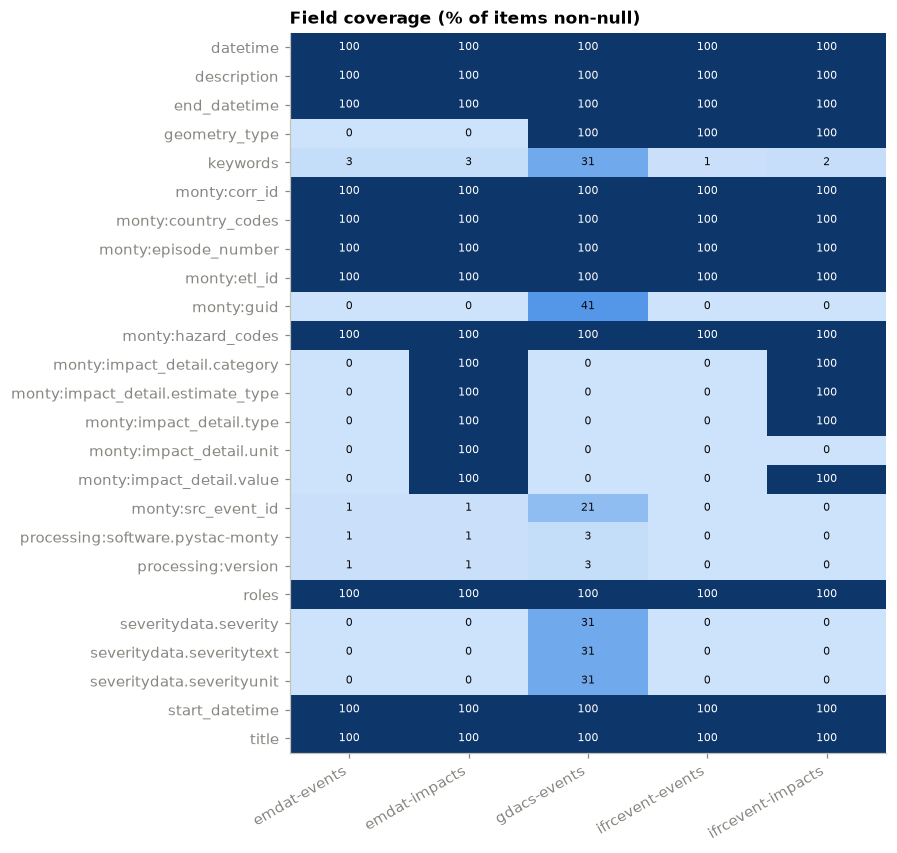

In [10]:
# Same table as a heatmap: dark = present, light = missing. The pale rows are the schema's required fields.
fields = coverage["field"].to_list()
cols = sorted(c for c in coverage.columns if c != "field")
mat = coverage.select(cols).to_numpy()

fig, ax = plt.subplots(figsize=(7, 0.3 * len(fields) + 1))
im = ax.imshow(mat, cmap=BLUES, vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(cols)), cols, rotation=30, ha="right")
ax.set_yticks(range(len(fields)), fields)
ax.grid(False)
# print the number in each cell so colour never carries the value alone
for i in range(len(fields)):
    for j in range(len(cols)):
        v = mat[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7, color="white" if v > 55 else INK)
ax.set_title("Field coverage (% of items non-null)")
plt.show()

## 2. ETL generations

`keywords` and `monty:src_event_id` aren't missing by *collection* — they're missing by *when the ETL ran*. Items dated 2025+ have `keywords`; items dated 2026 also have `monty:src_event_id` and `processing:version = 0.2.4` (`pystac-monty`). Everything older — ~97% of the bank — predates those fields. Same shape in every collection.

The ETL changelog (v1.0.0, 2026-06-30) describes "separate historical and latest pipelines": history was backfilled by an older code path. **Open question for IFRC:** will the historical pipeline be re-run on pystac-monty 0.2.4? If yes, the schema is right and we wait. If no, the schema needs `keywords` and `src_event_id` optional.

In [11]:
# Presence of the three "new ETL" fields, bucketed by the item's event year (a proxy for when it was loaded)
generations = (
    df.with_columns(pl.col("datetime").str.slice(0, 4).alias("year"))
    .group_by("collection", "year")
    .agg(
        pl.len().alias("n"),
        (pl.col("keywords").is_not_null().mean() * 100).round(0).alias("keywords_pct"),
        (pl.col("monty:src_event_id").is_not_null().mean() * 100).round(0).alias("src_event_id_pct"),
        (pl.col("processing:version").is_not_null().mean() * 100).round(0).alias("proc_version_pct"),
    )
    .filter(pl.col("year") >= "2022")  # everything earlier is 0% across the board
    .sort("collection", "year")
)
# Only one version string exists in the whole bank, so proc_version_pct == "% produced by pystac-monty 0.2.4"
print("processing:version values:", df["processing:version"].drop_nulls().unique().to_list())
generations

processing:version values: ['0.2.4']


collection,year,n,keywords_pct,src_event_id_pct,proc_version_pct
str,str,u32,f64,f64,f64
"""emdat-events""","""2022""",564,0.0,0.0,0.0
"""emdat-events""","""2023""",578,0.0,0.0,0.0
"""emdat-events""","""2024""",542,0.0,0.0,0.0
"""emdat-events""","""2025""",449,92.0,0.0,0.0
"""emdat-events""","""2026""",241,100.0,100.0,100.0
"""emdat-impacts""","""2022""",1520,0.0,0.0,0.0
"""emdat-impacts""","""2023""",1499,0.0,0.0,0.0
"""emdat-impacts""","""2024""",1543,0.0,0.0,0.0
"""emdat-impacts""","""2025""",1247,92.0,0.0,0.0


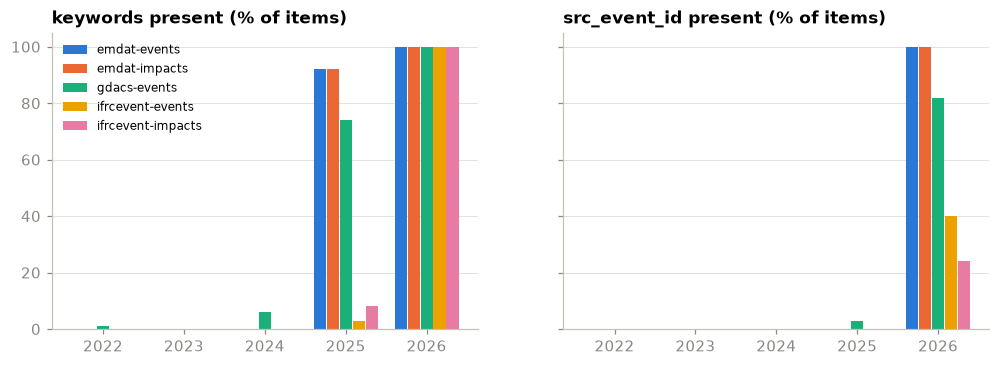

In [12]:
# One panel per field, one bar per collection per year. The step up in 2025/2026 is the same in every collection.
years = sorted(generations["year"].unique().to_list())
width = 0.15

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
for ax, col in zip(axes, ["keywords_pct", "src_event_id_pct"]):
    for k, cid in enumerate(frames):
        sub = generations.filter(pl.col("collection") == cid)
        pct = dict(zip(sub["year"], sub[col]))
        xs = [i + (k - 2) * (width + 0.01) for i in range(len(years))]  # offset each collection within the year group
        ax.bar(xs, [pct.get(y, 0) for y in years], width=width, color=COLL_COLOR[cid], label=cid)
    ax.set_xticks(range(len(years)), years)
    ax.set_title(f"{col.removesuffix('_pct')} present (% of items)")
    ax.grid(axis="x", visible=False)
axes[0].legend(loc="upper left")
plt.show()

## 3. Schema validation against real data

`MontandonItem.model_validate` on every cached item. EM-DAT gets a bbox-centre Point standing in for its excluded geometry, so this tests the schema, not our pull.

Pydantic tries all three `MontandonProperties` union members, so errors like `monty:hazard_detail missing` on an *event* are the hazard branch failing — noise. The root causes are the fields that fail on the *matching* branch: `monty:src_event_id` (99% EM-DAT/IFRC, 79% GDACS), `keywords` (97% / 69%), and `monty:impact_detail.unit` (99.7% of IFRC impacts).

The `embedding-setup` branch tightens `title`/`description` to non-blank (fine — 0 blanks found) and calls `properties.keywords` unconditionally in `extract_field_texts`, which will raise on ~97% of real items once validation passes.

Minimal schema change that validates the whole cache:
```python
keywords: list[str] = []
monty_src_event_id: str | None = Field(default=None, alias="monty:src_event_id")
# ImpactDetail
unit: str | None = None
```

In [13]:
def with_geometry(item: dict) -> dict:
    """Stand in a bbox-centre Point where geometry was excluded from the pull."""
    if item.get("geometry") is None and item.get("bbox"):
        b = item["bbox"]
        return {**item, "geometry": {"type": "Point", "coordinates": [(b[0] + b[2]) / 2, (b[1] + b[3]) / 2]}}
    return item

# summary: one row per collection (valid / invalid counts)
# reasons: one row per (collection, distinct error) with how many items hit it
summary, reasons = [], []
for cid, items in raw.items():
    n = ok = 0
    errs: Counter[str] = Counter()
    for it in items:
        n += 1
        try:
            MontandonItem.model_validate(with_geometry(it))
            ok += 1
        except ValidationError as e:
            # Count each distinct (location, error type) once per item, so an item with the same
            # field failing in all three union branches doesn't count three times
            seen = set()
            for err in e.errors():
                # Drop the union-branch name (MontandonEventProperties etc.) from the path so the
                # same underlying field failure collapses to one key
                loc = ".".join(str(x) for x in err["loc"] if not str(x).startswith("Montandon"))
                key = f"{loc} : {err['type']}"
                if key not in seen:
                    seen.add(key)
                    errs[key] += 1
    summary.append({"collection": cid, "n": n, "valid": ok, "invalid_pct": round(100 * (n - ok) / n, 1)})
    reasons += [{"collection": cid, "error": k, "items": v, "pct": round(100 * v / n, 1)} for k, v in errs.most_common()]

validation = pl.DataFrame(summary)
# Errors that hit <1% of a collection are noise from the union branches; drop them
validation_reasons = pl.DataFrame(reasons).filter(pl.col("pct") >= 1).sort("collection", "items", descending=[False, True])
validation

collection,n,valid,invalid_pct
str,i64,i64,f64
"""emdat-events""",25308,241,99.0
"""emdat-impacts""",64637,661,99.0
"""gdacs-events""",43723,9307,78.7
"""ifrcevent-events""",2199,4,99.8
"""ifrcevent-impacts""",1349,4,99.7


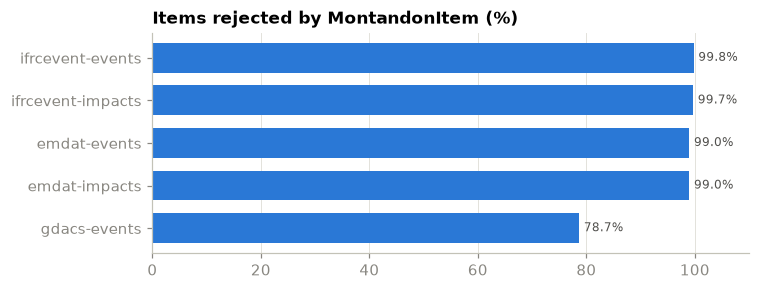

In [14]:
# Share of each collection the current schema rejects
v = validation.sort("invalid_pct", descending=True)
ax = hbar(v["collection"].to_list(), v["invalid_pct"].to_list(), "Items rejected by MontandonItem (%)", fmt="{:.1f}%")
ax.set_xlim(0, 110)
plt.show()

In [15]:
validation_reasons

collection,error,items,pct
str,str,i64,f64
"""emdat-events""","""properties.monty:src_event_id : missing""",25067,99.0
"""emdat-events""","""properties.monty:hazard_detail : missing""",25067,99.0
"""emdat-events""","""properties.created : missing""",25067,99.0
"""emdat-events""","""properties.forecasted : missing""",25067,99.0
"""emdat-events""","""properties.severitydata : missing""",25067,99.0
"""emdat-events""","""properties.advisory_number : missing""",25067,99.0
"""emdat-events""","""properties.monty:impact_detail : missing""",25067,99.0
"""emdat-events""","""properties.keywords : missing""",24655,97.4
"""emdat-impacts""","""properties.monty:src_event_id : missing""",63976,99.0


## 4. Text fields

What's actually in `title` and `description`? This decides which collection is a usable NLP / embedding corpus.

- **EM-DAT:** `Flood in Lushoto, Korogwe districts (Tanga region), United Republic of Tanzania of February 1993` — formulaic `<Hazard> in <Place>, <Country> of <Month Year>`. The only content not already in `hazard_codes` / `country_codes` / `datetime` is the sub-national place name.
- **GDACS:** `Green M 4.6 Earthquake in Indonesia at: 28 Apr 2005 04:48:13.` — fully templated. Embeddings will cluster by template, not by event.
- **IFRC:** `NA` for 85% of events; the rest is raw HTML from a rich-text editor. The ~300 real ones are long (p90 1.3k chars, max 79k) and are the only free-form narrative among the five collections pulled. Needs HTML stripping before any NLP.

Implication for the embedding track: `keywords` is embeddable on <1% of items, `description` is templated on the two big collections. Title/description similarity is still useful as a *matching feature* across sources; it's weak as a clustering target.

In [16]:
# Length distribution plus two placeholder detectors: the literal "NA" and anything that looks like an HTML tag
text_stats = (
    df.with_columns(
        pl.col("description").str.len_chars().alias("desc_len"),
        pl.col("title").str.len_chars().alias("title_len"),
    )
    .group_by("collection")
    .agg(
        pl.len().alias("n"),
        pl.col("desc_len").median().alias("desc_median"),
        pl.col("desc_len").quantile(0.9).alias("desc_p90"),
        pl.col("desc_len").max().alias("desc_max"),
        pl.col("description").n_unique().alias("desc_unique"),  # low vs n => templated / repeated text
        (pl.col("description") == "NA").sum().alias("desc_is_NA"),
        pl.col("description").str.contains("<[a-z]+").sum().alias("desc_has_html"),
        pl.col("title_len").median().alias("title_median"),
    )
    .sort("collection")
)
text_stats

collection,n,desc_median,desc_p90,desc_max,desc_unique,desc_is_NA,desc_has_html,title_median
str,u32,f64,f64,u32,u32,u32,u32,f64
"""emdat-events""",25308,65.0,151.0,2909,25196,0,0,28.0
"""emdat-impacts""",64637,70.0,171.0,2124,24369,0,0,43.0
"""gdacs-events""",43723,63.0,78.0,343,30427,0,0,23.0
"""ifrcevent-events""",2199,2.0,1258.0,78932,326,1871,268,21.0
"""ifrcevent-impacts""",1349,503.0,4367.0,78932,218,641,613,38.0


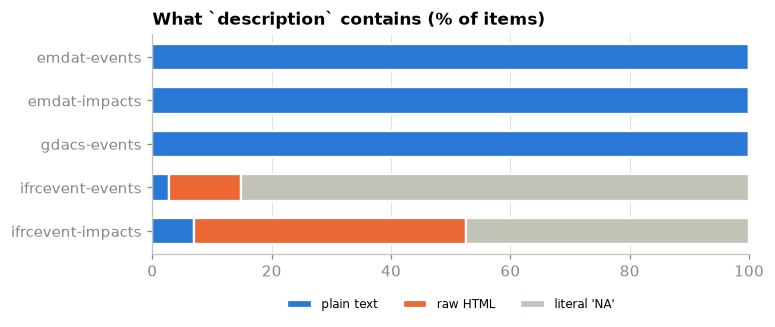

In [17]:
# What each collection's `description` actually holds. NA and HTML never overlap, so the three parts sum to 100.
comp = text_stats.select(
    "collection",
    (pl.col("desc_is_NA") / pl.col("n") * 100).alias("literal 'NA'"),
    (pl.col("desc_has_html") / pl.col("n") * 100).alias("raw HTML"),
).with_columns((100 - pl.col("literal 'NA'") - pl.col("raw HTML")).alias("plain text"))

fig, ax = plt.subplots(figsize=(7, 2.6))
left = [0.0] * comp.height
for name, color in [("plain text", COLORS[0]), ("raw HTML", COLORS[1]), ("literal 'NA'", AXIS)]:
    vals = comp[name].to_list()
    ax.barh(comp["collection"].to_list(), vals, left=left, color=color, label=name, height=0.6, edgecolor="white", linewidth=1.5)
    left = [l + v for l, v in zip(left, vals)]
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.grid(axis="y", visible=False)
ax.set_title("What `description` contains (% of items)")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.15))
plt.show()

In [18]:
for cid in raw:
    print(f"--- {cid} ---")
    for d in frames[cid].sample(4, seed=1)["description"].to_list():
        print("  ", d[:160].replace("\n", " "))

--- emdat-events ---
   Explosion (Miscellaneous) in Mexico city, Mexico of December 1988
   Earthquake in Nehbandan area, Iran (Islamic Republic of) of January 1993
   Flood in Castellón and Valencia Provinces (Valencian Community); Tarragona, Toledo, Spain of August 2021
   Road in Between Turin - Milan, Italy of February 1993
--- emdat-impacts ---
   Drought in Regions VI, IX, X, XI and XII, Philippines of December 1990
   Storm in Dinant, Liege regions, Belgium of January 1995
   Flood in East Aceh and Aceh Tamiang (Aceh Province, northern Sumatra), Indonesia of December 2021
   Earthquake in Paphos, Nicosia areas, Cyprus of February 1995
--- gdacs-events ---
   Green M 4.8 Earthquake in Indonesia at: 28 Apr 2005 09:36:43.
   Green M 5.2 Earthquake in Iran at: 30 Mar 2006 19:36:17.
   Green Tropical Cyclone LALA-26 in United States from: 12 Aug 2026 to: 28 Aug 2026 .
   Green M 4.3 Earthquake in Brazil at: 03 Apr 2006 03:33:47.
--- ifrcevent-events ---
   NA
   NA
   <p class="MsoN

In [19]:
# The IFRC "description" field is a placeholder 85% of the time
frames["ifrcevent-events"].group_by("description").len().sort("len", descending=True).head(5)

description,len
str,u32
"""NA""",1871
"""<br data-mce-bogus=""1"">""",4
"""<p class=""MsoNormal"" style=""text-align: justify; line-height: normal;""…",1
"""<p><strong>A magnitude 7.3 earthquake </strong>hit near Port Vila, Van…",1
"""<p>Due to its quasi-tropical climate, Burundi is at enormous risk of f…",1


## 5. `monty:corr_id` linkage

`corr_id` is the documented cross-source correlation key. How well does it actually link?

- **Within-source:** every EM-DAT impact and every IFRC impact joins to an event on `corr_id` (100%).
- **Cross-source:** only 470 of 56,712 event `corr_id`s (0.8%) appear in more than one source collection.

In [20]:
# For every corr_id: which collections it appears in, and how many items share it
corr = df.group_by("monty:corr_id").agg(
    pl.col("collection").unique().sort().alias("collections"),
    pl.len().alias("n_items"),
)
# Roll up by the *set* of collections — e.g. ["emdat-events", "emdat-impacts"] is the within-source link,
# anything mixing emdat / gdacs / ifrcevent is a cross-source link
linkage = corr.group_by("collections").agg(
    pl.len().alias("n_corr_ids"),
    pl.col("n_items").sum().alias("n_items"),
).sort("n_corr_ids", descending=True)

# Cross-source rate, counted on event collections only (impacts always share their own event's corr_id)
events = df.filter(pl.col("collection").str.ends_with("-events"))
n_sources = events.group_by("monty:corr_id").agg(pl.col("collection").n_unique().alias("n_sources"))
multi = n_sources.filter(pl.col("n_sources") > 1).height
print(f"unique corr_ids: {corr.height:,}")
print(f"event corr_ids seen in >1 source: {multi:,} of {n_sources.height:,} ({100 * multi / n_sources.height:.1f}%)")

# Within-source rate: what share of impacts semi-join to an event on corr_id (GDACS has no impacts pulled)
for src in ["emdat", "ifrcevent"]:
    ev, im = frames[f"{src}-events"], frames[f"{src}-impacts"]
    joined = im.join(ev.select("monty:corr_id").unique(), on="monty:corr_id", how="semi").height
    print(f"{src}-impacts -> {src}-events join: {100 * joined / im.height:.1f}%")
linkage

unique corr_ids: 56,715
event corr_ids seen in >1 source: 470 of 56,712 (0.8%)
emdat-impacts -> emdat-events join: 100.0%
ifrcevent-impacts -> ifrcevent-events join: 100.0%


collections,n_corr_ids,n_items
list[str],u32,u32
"[""gdacs-events""]",29507,43203
"[""emdat-events"", ""emdat-impacts""]",23855,87100
"[""ifrcevent-events""]",1723,1724
"[""emdat-events""]",828,830
"[""ifrcevent-events"", ""ifrcevent-impacts""]",329,1426
"[""emdat-events"", ""emdat-impacts"", ""gdacs-events""]",327,1915
"[""emdat-events"", ""emdat-impacts"", ""ifrcevent-events""]",50,306
"[""emdat-events"", ""emdat-impacts"", … ""ifrcevent-impacts""]",48,435
"[""gdacs-events"", ""ifrcevent-events"", ""ifrcevent-impacts""]",21,105


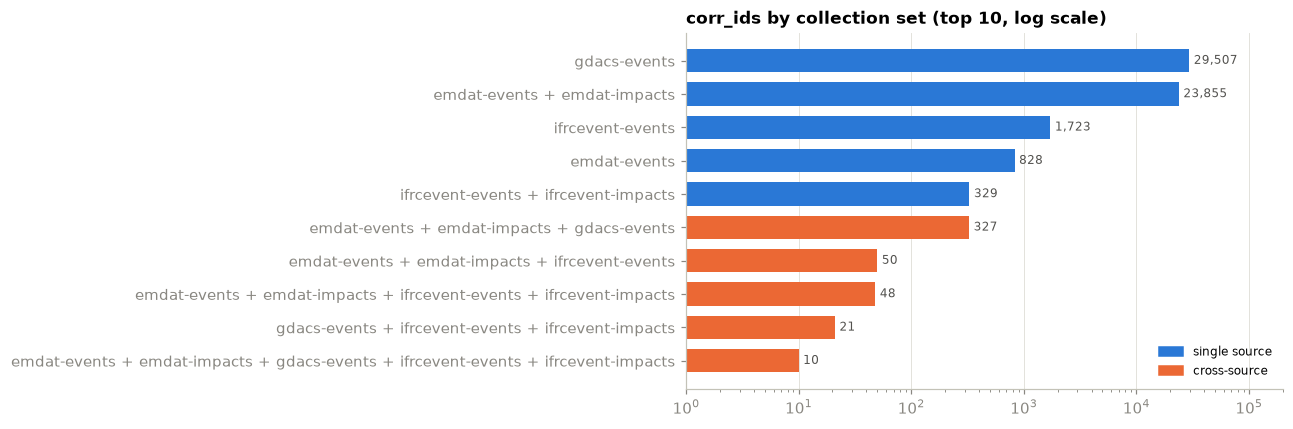

In [21]:
# corr_ids by the set of collections they appear in. Orange = the set spans more than one source.
# Log x-axis: the cross-source sets are two orders of magnitude smaller and vanish on a linear scale.
top = linkage.head(10)
sets = top["collections"].to_list()
cross = [len({c.split("-")[0] for c in s}) > 1 for s in sets]
ax = hbar(
    [" + ".join(s) for s in sets],
    top["n_corr_ids"].to_list(),
    "corr_ids by collection set (top 10, log scale)",
    color=[COLORS[1] if x else COLORS[0] for x in cross],
)
ax.set_xscale("log")
ax.set_xlim(1, 2e5)
ax.legend(handles=[Patch(color=COLORS[0], label="single source"), Patch(color=COLORS[1], label="cross-source")], loc="lower right")
plt.show()

### Why it can't work across sources

From the ETL repo (`pystac_monty/paring.py`), `corr_id` is deterministic:
`{YYYYMMDD}-{country}-{geoblock}-{hazard_cluster}-{episode}-GCDB`. Three format generations coexist in the bank, and **GDACS puts its own event ID in the `episode` slot** (`…-GH0101-1732529-GCDB`) where EM-DAT and IFRC put `1`. So a GDACS and an EM-DAT record of the same event can never share a `corr_id`, in any format. The geoblock in the current format makes matching stricter still — the current-format IDs have a **0.0%** cross-source rate.

IFRC's own cookbook (recipe 07, Türkiye–Syria 2023) doesn't use `corr_id` across sources either: it links by `bbox` + `datetime` window + a hand-enumerated list of hazard codes across every vocabulary. That's the approach to replicate, with the crosswalk replacing the hand-typed lists.

In [22]:
# corr_id format generations. Current format has a numeric geoblock between country and cluster:
#   current: 20260828-ZWE-638247-TL0405-1-GCDB   older: 20251216-IDN-MH0600-1-GCDB
CURRENT = r"^\d{8}-[A-Z]{3}-\d+-[A-Z]{2}\d{4}-\d+-GCDB$"
ev_fmt = (
    df.filter(pl.col("collection").str.ends_with("-events"))
    .with_columns(
        pl.col("datetime").str.slice(0, 4).alias("year"),
        pl.col("monty:corr_id").str.contains(CURRENT).alias("current_format"),
    )
)
# How many events per collection are on each format, with an example ID of each
print(ev_fmt.group_by("collection", "current_format").agg(pl.len().alias("n"), pl.col("monty:corr_id").first().alias("example")).sort("collection", "current_format"))
print()

# Cross-source rate split by format — does the stricter current format link *better* or *worse*?
by_fmt = ev_fmt.group_by("monty:corr_id").agg(pl.col("collection").n_unique().alias("n_src"), pl.col("current_format").first())
by_fmt.group_by("current_format").agg(
    pl.len().alias("corr_ids"),
    (pl.col("n_src") > 1).sum().alias("multi_source"),
    ((pl.col("n_src") > 1).mean() * 100).round(2).alias("multi_source_pct"),
)

shape: (6, 4)
┌──────────────────┬────────────────┬───────┬─────────────────────────────────────────┐
│ collection       ┆ current_format ┆ n     ┆ example                                 │
│ ---              ┆ ---            ┆ ---   ┆ ---                                     │
│ str              ┆ bool           ┆ u32   ┆ str                                     │
╞══════════════════╪════════════════╪═══════╪═════════════════════════════════════════╡
│ emdat-events     ┆ false          ┆ 25067 ┆ 20251216-IDN-MH0600-1-GCDB              │
│ emdat-events     ┆ true           ┆ 241   ┆ 20260828-ZWE-638247-TL0405-1-GCDB       │
│ gdacs-events     ┆ false          ┆ 33651 ┆ 20260309-GTM-GH0101-1691930-GCDB        │
│ gdacs-events     ┆ true           ┆ 10072 ┆ 20260911-COL-848317-GH0101-1732529-GCDB │
│ ifrcevent-events ┆ false          ┆ 2194  ┆ 20260406-SLB-MH0306-1-GCDB              │
│ ifrcevent-events ┆ true           ┆ 5     ┆ 20260826-NPL-1065121-MH0600-1-GCDB      │
└─────────────────

current_format,corr_ids,multi_source,multi_source_pct
bool,u32,u32,f64
false,46415,470,1.01
true,10297,0,0.0


## 6. Categoricals and geometry

- **Hazard codes:** most items carry one code, but ~27k carry 3 or 5 — one per taxonomy. Top values mix EM-DAT (`nat-hyd-flo-riv`), UNDRR-ISC (`GH0001`, `EN0013`), and GLIDE (`FL`, `WF`) vocabularies in the same field. The ETL repo's `HazardProfiles.csv` (303 rows) crosswalks all of them to a `cluster_label` / `family_label`.
- **Countries:** 98% single-country.
- **Geometry:** GDACS = Point; IFRC = Polygon/MultiPolygon; EM-DAT = country MultiPolygons (excluded here).
- **Date ranges:** EM-DAT 1900–2026; GDACS 2000–2026; IFRC 1970–2026.

In [23]:
# hazard_codes is a list column: 1 code = one vocabulary; 3 or 5 = the same hazard tagged in every vocabulary
print("hazard codes per item:")
print(df["monty:hazard_codes"].list.len().value_counts().sort("monty:hazard_codes"))
print("\ntop hazard codes (note the mixed vocabularies — EM-DAT `nat-hyd-flo-riv`, UNDRR `GH0001`, GLIDE `FL`):")
# explode so each code counts once per item it appears on
df.explode("monty:hazard_codes").group_by("monty:hazard_codes").len().sort("len", descending=True).head(15)

hazard codes per item:
shape: (4, 2)
┌────────────────────┬────────┐
│ monty:hazard_codes ┆ count  │
│ ---                ┆ ---    │
│ u32                ┆ u32    │
╞════════════════════╪════════╡
│ 1                  ┆ 108948 │
│ 2                  ┆ 871    │
│ 3                  ┆ 16857  │
│ 5                  ┆ 10540  │
└────────────────────┴────────┘

top hazard codes (note the mixed vocabularies — EM-DAT `nat-hyd-flo-riv`, UNDRR `GH0001`, GLIDE `FL`):


/var/folders/0s/rn0t7r9s2jl33n8wchyp4f600000gn/T/ipykernel_54509/2330834809.py:6: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  df.explode("monty:hazard_codes").group_by("monty:hazard_codes").len().sort("len", descending=True).head(15)


monty:hazard_codes,len
str,u32
"""EN0013""",13044
"""nat-cli-wil-wil""",11318
"""nat-met-sto-tro""",11274
"""WF""",10983
"""nat-hyd-flo-riv""",10708
"""EN0205""",10597
"""GH0001""",10446
"""GH0002""",10446
"""GH0005""",10446


/var/folders/0s/rn0t7r9s2jl33n8wchyp4f600000gn/T/ipykernel_54509/1422920403.py:12: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  top_codes = df.explode("monty:hazard_codes").group_by("monty:hazard_codes").len().sort("len", descending=True).head(15)


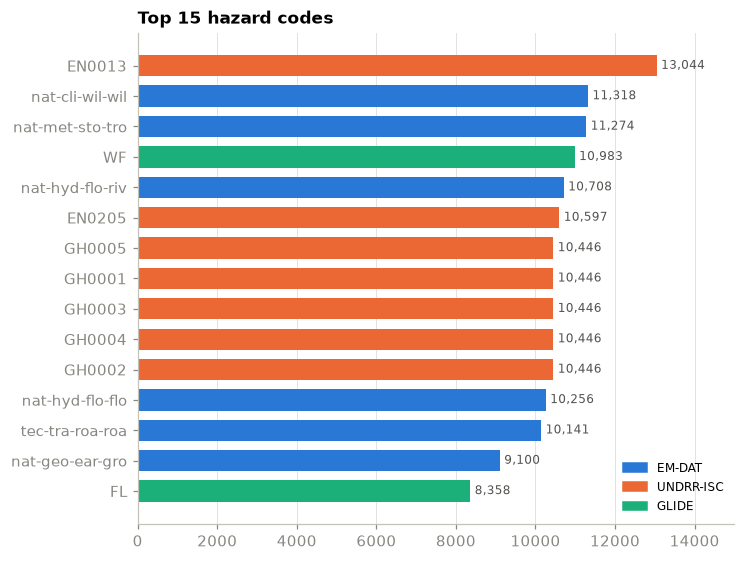

/var/folders/0s/rn0t7r9s2jl33n8wchyp4f600000gn/T/ipykernel_54509/1422920403.py:20: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  df.explode("monty:hazard_codes")


vocab,len
str,u32
"""EM-DAT""",104824
"""UNDRR-ISC""",84790
"""GLIDE""",24253
"""other""",94


In [24]:
# Top hazard codes, coloured by which vocabulary the code belongs to
def vocab(code: str) -> str:
    if re.fullmatch(r"[A-Z]{2}\d{4}", code):
        return "UNDRR-ISC"
    if re.fullmatch(r"[A-Z]{2}", code):
        return "GLIDE"
    if re.fullmatch(r"[a-z]{3}(-[a-z]{3})+", code):
        return "EM-DAT"
    return "other"

VOCAB_COLOR = {"EM-DAT": COLORS[0], "UNDRR-ISC": COLORS[1], "GLIDE": COLORS[2], "other": AXIS}
top_codes = df.explode("monty:hazard_codes").group_by("monty:hazard_codes").len().sort("len", descending=True).head(15)
codes = top_codes["monty:hazard_codes"].to_list()
ax = hbar(codes, top_codes["len"].to_list(), "Top 15 hazard codes", color=[VOCAB_COLOR[vocab(c)] for c in codes])
ax.legend(handles=[Patch(color=c, label=v) for v, c in VOCAB_COLOR.items() if v != "other"], loc="lower right")
plt.show()

# and how the whole field splits by vocabulary
vocab_counts = (
    df.explode("monty:hazard_codes")
    .with_columns(pl.col("monty:hazard_codes").map_elements(vocab, return_dtype=pl.String).alias("vocab"))
    .group_by("vocab").len().sort("len", descending=True)
)
vocab_counts

In [25]:
# Same shape as hazard codes: how many countries per item, then the most-tagged countries
print("countries per item:")
print(df["monty:country_codes"].list.len().value_counts().sort("monty:country_codes"))
print("\ntop countries:")
df.explode("monty:country_codes").group_by("monty:country_codes").len().sort("len", descending=True).head(10)

countries per item:
shape: (14, 2)
┌─────────────────────┬────────┐
│ monty:country_codes ┆ count  │
│ ---                 ┆ ---    │
│ u32                 ┆ u32    │
╞═════════════════════╪════════╡
│ 1                   ┆ 134482 │
│ 2                   ┆ 2358   │
│ 3                   ┆ 134    │
│ 4                   ┆ 80     │
│ 5                   ┆ 106    │
│ 6                   ┆ 11     │
│ 7                   ┆ 4      │
│ 8                   ┆ 18     │
│ 9                   ┆ 2      │
│ 10                  ┆ 1      │
│ 14                  ┆ 1      │
│ 15                  ┆ 1      │
│ 16                  ┆ 1      │
│ 26                  ┆ 17     │
└─────────────────────┴────────┘

top countries:


/var/folders/0s/rn0t7r9s2jl33n8wchyp4f600000gn/T/ipykernel_54509/212966437.py:5: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  df.explode("monty:country_codes").group_by("monty:country_codes").len().sort("len", descending=True).head(10)


monty:country_codes,len
str,u32
"""CHN""",8214
"""USA""",7180
"""IND""",6358
"""IDN""",5692
"""RUS""",5136
"""PHL""",4895
"""AUS""",4848
"""BRA""",3305
"""JPN""",3105


/var/folders/0s/rn0t7r9s2jl33n8wchyp4f600000gn/T/ipykernel_54509/552715687.py:1: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  top_countries = df.explode("monty:country_codes").group_by("monty:country_codes").len().sort("len", descending=True).head(15)


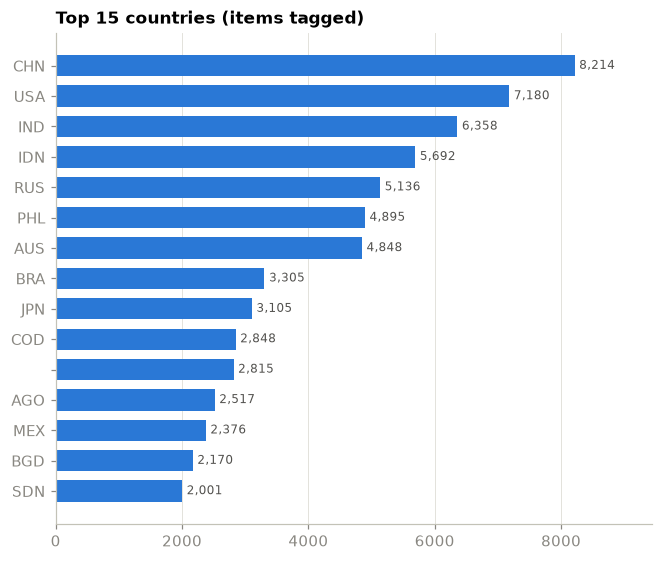

In [26]:
top_countries = df.explode("monty:country_codes").group_by("monty:country_codes").len().sort("len", descending=True).head(15)
hbar(top_countries["monty:country_codes"].to_list(), top_countries["len"].to_list(), "Top 15 countries (items tagged)")
plt.show()

In [27]:
# Geometry types (EM-DAT is null because we pulled it with geometry=False)
print(df.group_by("collection", "geometry_type").len().sort("collection"))
# Date span per collection
print(df.group_by("collection").agg(
    pl.col("datetime").min().str.slice(0, 10).alias("min_date"),
    pl.col("datetime").max().str.slice(0, 10).alias("max_date"),
).sort("collection"))
# What EM-DAT impact records actually measure
frames["emdat-impacts"].group_by("monty:impact_detail.category", "monty:impact_detail.type").len().sort("len", descending=True)

shape: (7, 3)
┌───────────────────┬───────────────┬───────┐
│ collection        ┆ geometry_type ┆ len   │
│ ---               ┆ ---           ┆ ---   │
│ str               ┆ str           ┆ u32   │
╞═══════════════════╪═══════════════╪═══════╡
│ emdat-events      ┆ null          ┆ 25308 │
│ emdat-impacts     ┆ null          ┆ 64637 │
│ gdacs-events      ┆ Point         ┆ 43723 │
│ ifrcevent-events  ┆ MultiPolygon  ┆ 981   │
│ ifrcevent-events  ┆ Polygon       ┆ 1218  │
│ ifrcevent-impacts ┆ MultiPolygon  ┆ 684   │
│ ifrcevent-impacts ┆ Polygon       ┆ 665   │
└───────────────────┴───────────────┴───────┘
shape: (5, 3)
┌───────────────────┬────────────┬────────────┐
│ collection        ┆ min_date   ┆ max_date   │
│ ---               ┆ ---        ┆ ---        │
│ str               ┆ str        ┆ str        │
╞═══════════════════╪════════════╪════════════╡
│ emdat-events      ┆ 1900-01-01 ┆ 2026-08-28 │
│ emdat-impacts     ┆ 1900-01-01 ┆ 2026-08-28 │
│ gdacs-events      ┆ 2000-01-01 ┆ 202

monty:impact_detail.category,monty:impact_detail.type,len
str,str,u32
"""people""","""affected_total""",27284
"""people""","""death""",20198
"""people""","""injured""",8620
"""total_affected""","""cost""",5843
"""people""","""displaced_total""",2692


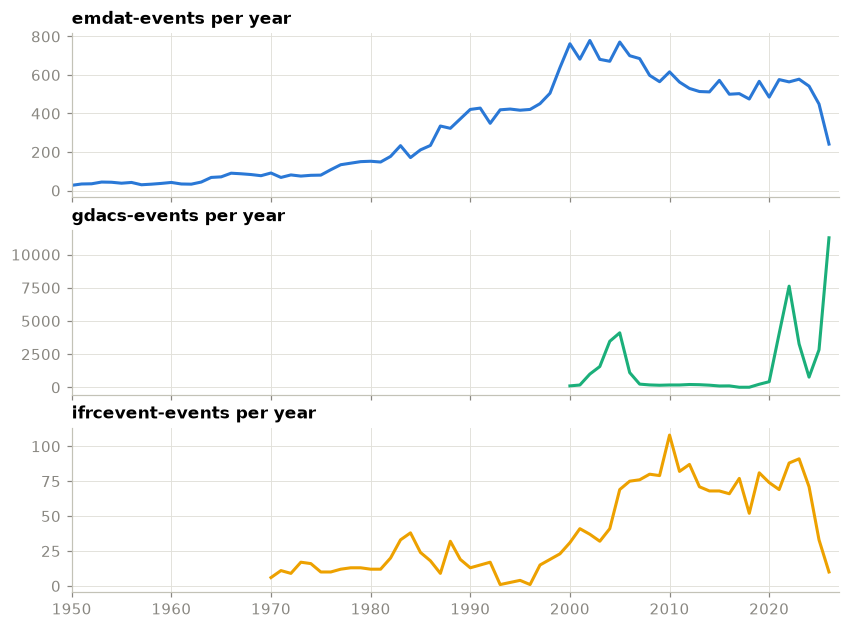

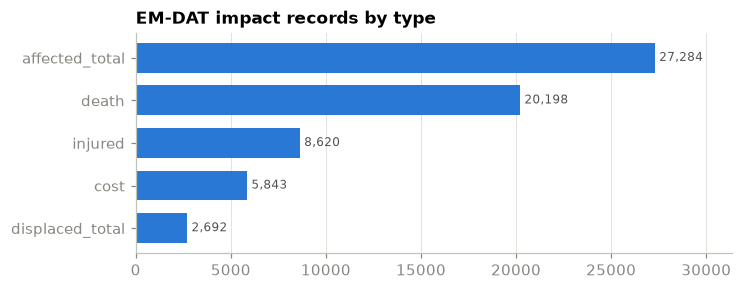

In [28]:
# Events per year, one panel per collection (own y-scale each — GDACS's spikes would flatten the others).
# EM-DAT is steady from ~1990; GDACS is patchy (2004–05, 2022, 2026 only), consistent with the staging DB still loading.
per_year = (
    df.filter(pl.col("collection").str.ends_with("-events"))
    .with_columns(pl.col("datetime").str.slice(0, 4).cast(pl.Int32).alias("year"))
    .group_by("collection", "year").len()
    .sort("collection", "year")
)
event_colls = per_year["collection"].unique().sort().to_list()
fig, axes = plt.subplots(len(event_colls), 1, figsize=(9, 2.2 * len(event_colls)), sharex=True)
for ax, cid in zip(axes, event_colls):
    sub = per_year.filter(pl.col("collection") == cid)
    ax.plot(sub["year"], sub["len"], color=COLL_COLOR[cid], linewidth=2)
    ax.set_title(f"{cid} per year")
axes[-1].set_xlim(1950, 2027)  # pre-1950 EM-DAT is a handful of items per year
plt.show()

# What EM-DAT impacts actually measure
impact_types = frames["emdat-impacts"].group_by("monty:impact_detail.type").len().sort("len", descending=True)
hbar(impact_types["monty:impact_detail.type"].to_list(), impact_types["len"].to_list(), "EM-DAT impact records by type")
plt.show()

## What the upstream repos tell us

Two IFRC repos explain most of the above. 

**[`IFRCGo/montandon-etl`](https://github.com/IFRCGo/montandon-etl)** (+ `pystac-monty` submodule) — the ETL that produces every item.
- `keywords = hazard_profiles.get_keywords(hazard_codes) + country_codes` in every source. Derived, not sourced.
- `paring.py` — the `corr_id` construction above.
- `HazardProfiles.csv` — the hazard-code crosswalk. `geo_blocks-0.2.parquet` — the spatial grid.
- `extension.py` — canonical field list and enums (`MontyRoles`, `MontyImpactType`, `MontyResponseType`, …) and a `monty:response_detail` object we haven't seen because no response collection has data yet. Schema URI `monty-stac-extension/v1.3.0`.

**[`IFRCGo/montandon-notebooks`](https://github.com/IFRCGo/montandon-notebooks)** ([cookbook](https://ifrcgo.org/montandon-notebooks/)) — nine recipes.
- Recipe 07 links across sources by date + bbox + hazard code, not `corr_id`.
- Recipe 08: the API supports **CQL2 filtering server-side** — `a_overlaps` on `monty:hazard_codes`, `a_contains` on `monty:country_codes`, `t_intersects` on `datetime`, comparisons on `monty:impact_detail.type/.value`. `/queryables` lists filterable fields. Targeted questions don't need a full pull. Filter by *collection*, not `roles` (server bug).
- Per-source field mapping docs at `monty-stac-extension/model/sources/<SOURCE>`, linked from each collection's `describedby`.

## API behaviour worth knowing

- No `numberMatched` anywhere; counting means paging IDs.
- ~30 s gateway timeout; the server drops connections under load with no error. `pystac_client.Client.open(timeout=…)` is the only thing that stops a hang `get_pystac_client()` doesn't set it.
- `fields={"exclude": ["geometry"]}` is honoured server-side.